<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Подготовка" data-toc-modified-id="Подготовка-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Подготовка</a></span></li><li><span><a href="#Обучение" data-toc-modified-id="Обучение-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Обучение</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Выводы</a></span></li><li><span><a href="#Чек-лист-проверки" data-toc-modified-id="Чек-лист-проверки-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Чек-лист проверки</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Обучите модель классифицировать комментарии на позитивные и негативные. В вашем распоряжении набор данных с разметкой о токсичности правок.

Постройте модель со значением метрики качества *F1* не меньше 0.75. 

**Инструкция по выполнению проекта**

1. Загрузите и подготовьте данные.
2. Обучите разные модели. 
3. Сделайте выводы.

Для выполнения проекта применять *BERT* необязательно, но вы можете попробовать.

**Описание данных**

Данные находятся в файле `toxic_comments.csv`. Столбец *text* в нём содержит текст комментария, а *toxic* — целевой признак.

In [1]:
!pip install -q wordcloud
!pip install -q wordcloud==1.8.2.2  
!pip install -q --upgrade Pillow

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
from lightgbm.sklearn import LGBMClassifier
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import (accuracy_score,
recall_score,
precision_score,
roc_auc_score,
f1_score,
confusion_matrix,
roc_auc_score,
f1_score,
fbeta_score,
precision_recall_curve,
auc,
roc_curve,                            
classification_report) 
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer 
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from pymystem3 import Mystem
import re 
from sklearn.pipeline import Pipeline

from tqdm.notebook import tqdm #использование progress.apply
tqdm.pandas() #использование progress.apply

TEST_SIZE = 0.25
RANDOM_STATE = 12345 

In [4]:
#Настройки пандас
pd.set_option('display.max_columns', None)# Отображение всех столбцов в таблице;
pd.set_option('display.max_rows', None) # Отображение всех строк в таблице;
pd.set_option('display.max_colwidth', None) # текст в ячейке отражался полностью вне зависимости от длины;
pd.set_option('display.float_format', '{:.2f}'.format) #-все числа отражались с двумя знаками после запятой;
#pd.options.display.float_format = '{:20,.2f}'.format 

In [5]:
import nltk 
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer() # инициализируем лемматизатор
from nltk.corpus import wordnet, stopwords 
from spacy.lang.de.stop_words import STOP_WORDS
#from nltk.probability import FreqDist
#from nltk.tokenize import word_tokenize

#from wordcloud import WordCloud
from nltk.probability import FreqDist

from sklearn.utils import shuffle

[nltk_data] Downloading package punkt to /home/jovyan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/jovyan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/jovyan/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


## Подготовка

In [6]:
data=pd.read_csv('/datasets/toxic_comments.csv', index_col=0)
data_bert=data.sample(500).reset_index(drop=True).copy()

BERT

In [7]:
!pip install torch

In [8]:
import numpy as np
import pandas as pd
import torch
import transformers 
from transformers import BertModel
from tqdm import notebook
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

In [9]:
model = transformers.AutoModel.from_pretrained('unitary/toxic-bert')
tokenizer = transformers.AutoTokenizer.from_pretrained('unitary/toxic-bert')

Downloading:   0%|          | 0.00/811 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/418M [00:00<?, ?B/s]

Some weights of the model checkpoint at unitary/toxic-bert were not used when initializing BertModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Downloading:   0%|          | 0.00/174 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/226k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [10]:
# Загрузка словаря модели BERT
#tokenizer = transformers.BertTokenizer(
#    vocab_file='/datasets/ds_bert/vocab.txt')

In [11]:
# Токенизация текстов твитов 
# с добавлением токенов начала и конца текста
tokenized = data_bert['text'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True))
# целево признак
bert_y= data_bert['toxic']

Token indices sequence length is longer than the specified maximum sequence length for this model (735 > 512). Running this sequence through the model will result in indexing errors


In [12]:
# Определение максимальной длины токена
max_len = 0
for i in tokenized.values:
    if len(i) > max_len:
        max_len = len(i)

print('Максимальная длина токена:', max_len) 

Максимальная длина токена: 1111


In [13]:
# Приведение токенов к единой максимальной длине
padded = np.array([i + [0]*(max_len - len(i)) for i in tokenized.values])
# Уменьшение размерности токенов
padded = padded[:, :512] 

In [14]:
# "Маскировка" нулями (пустота) и единицами (текст) токенов.
attention_mask = np.where(padded != 0, 1, 0)

In [12]:
#Модель указанная в обучении
config = transformers.BertConfig.from_json_file(
    '/datasets/ds_bert/bert_config.json')
#model = BertModel.from_pretrained('bert-base-uncased')
model = transformers.BertModel.from_pretrained(
    '/datasets/ds_bert/rubert_model.bin', config=config)

Some weights of the model checkpoint at /datasets/ds_bert/rubert_model.bin were not used when initializing BertModel: ['cls.predictions.decoder.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [13]:
#Нашел еще такой вариант
#model = BertModel.from_pretrained('bert-base-uncased')

In [15]:
batch_size = 25 # эмбеддинги BERT создаёт батчами
embeddings = []
for i in notebook.tqdm(range(padded.shape[0] // batch_size)):
        batch = torch.LongTensor(padded[batch_size*i:batch_size*(i+1)]) 
        attention_mask_batch = torch.LongTensor(attention_mask[batch_size*i:batch_size*(i+1)])
        
        with torch.no_grad():
            batch_embeddings = model(batch, attention_mask=attention_mask_batch)
        
        embeddings.append(batch_embeddings[0][:,0,:].numpy())

  0%|          | 0/20 [00:00<?, ?it/s]

In [16]:
features = np.concatenate(embeddings)

In [17]:
bert_X_train, bert_X_test, bert_y_train, bert_y_test = train_test_split(features, bert_y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print(bert_X_train.shape)
print(bert_y_train.shape)
print(bert_X_test.shape)
print(bert_y_test.shape)

(375, 768)
(375,)
(125, 768)
(125,)


In [18]:
# зададим алгоритм для модели
model = LogisticRegression(random_state=RANDOM_STATE)

In [19]:
# обучим модель
model.fit(bert_X_train, bert_y_train)
 
predictions = model.predict(bert_X_train)
f1 = f1_score(bert_y_train, predictions)
print(f1)

1.0


In [20]:
#Тренировочные
predictions = model.predict(bert_X_test)
f1 = f1_score(bert_y_test, predictions)
print(f1)

0.888888888888889


In [6]:
def data_info(df):
#Общая инвормация
#    print('Информация по',return(df))
    print('Количество строк - ', df.shape[0])
    print('Количество столбцов -', df.shape[1],end='\n\n')
    df.info()
    print()
    display(df.head(3))
#поиск пропусков    
    isnaPD = pd.concat([(df.isna().sum()),((df.isna().sum()/df.isna().count()*100).round(2))], axis =1)
    isnaPD.columns= ['Количество пропусков','% пропусков']
    display(isnaPD)
#Поиск явных дубликатов
    print()
    print('Количество явных дубликатов в данных:',df.duplicated().sum(),end='\n')
    print('Доля явных дубликатов:', round(df.duplicated().sum()/df.shape[0]*100, 2),'%',end='\n\n')
#Проверка на неявные дубликаты
    cat_col_names = df.select_dtypes(exclude='number').columns.tolist()
    for i in cat_col_names:
        print (df[i].unique())
        print()

In [7]:
data_info(data)

Количество строк -  159292
Количество столбцов - 2

<class 'pandas.core.frame.DataFrame'>
Int64Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB



,text,toxic
0,"Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27",0
1,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, January 11, 2016 (UTC)",0
2,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info.",0


,Количество пропусков,% пропусков
text,0,0.00
toxic,0,0.00



Количество явных дубликатов в данных: 0
Доля явных дубликатов: 0.0 %

["Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They weren't vandalisms, just closure on some GAs after I voted at New York Dolls FAC. And please don't remove the template from the talk page since I'm retired now.89.205.38.27"
 "D'aww! He matches this background colour I'm seemingly stuck with. Thanks.  (talk) 21:51, January 11, 2016 (UTC)"
 "Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page. He seems to care more about the formatting than the actual info."
 ...
 'Spitzer \n\nUmm, theres no actual article for prostitution ring.  - Crunch Captain.'
 'And it looks like it was actually you who put on the speedy to have the first version deleted now that I look at it.'
 '"\nAnd ... I really don\'t think you understand.  I came here and my idea was bad right away.

In [8]:
corpus = list(data['text'])

In [9]:
# посмотрим на среднюю и максимальную длину комментария в корпусе
len_sents = []
for sentence in corpus:
    len_sents.append(len(sentence))
print(sum(len_sents)/len(len_sents))
print(max(len_sents))

393.69130276473396
5000


В корпусе комментариев 159 292 записи. 
Прорусков и дубликатов нет.
Срденяя длина записи 394 символа, максимальная 5000.

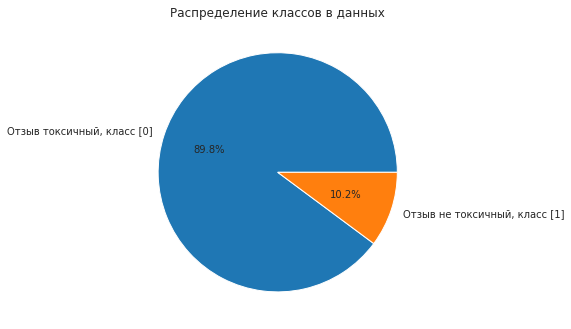

In [10]:
sns.set_style('darkgrid')
data['toxic'].value_counts(normalize=True).plot(kind='pie',figsize=[5.5,5.5], legend=False, autopct='%1.1f%%',labels=['Отзыв токсичный, класс [0]','Отзыв не токсичный, класс [1]'])
plt.title('Распределение классов в данных')
plt.ylabel('')
plt.show()

В данных преобладает токсичный класс.

In [11]:
'''
def get_wordnet_pos(word):
    """Map POS tag to first character lemmatize() accepts"""
    tag = nltk.pos_tag([word]) upper() [1](https://gist.github.com/prassena/029a6510868c0180989efaebdee2a330)
    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}
    return tag_dict.get(tag, wordnet.NOUN)
    '''

'\ndef get_wordnet_pos(word):\n    """Map POS tag to first character lemmatize() accepts"""\n    tag = nltk.pos_tag([word]) upper() [1](https://gist.github.com/prassena/029a6510868c0180989efaebdee2a330)\n    tag_dict = {"J": wordnet.ADJ, "N": wordnet.NOUN, "V": wordnet.VERB, "R": wordnet.ADV}\n    return tag_dict.get(tag, wordnet.NOUN)\n    '

In [12]:
# функция для добавления частеречного тега в лемматизаторе
def get_wordnet_pos(word):
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "N": wordnet.NOUN,
                "V": wordnet.VERB,
                "R": wordnet.ADV}

    return tag_dict.get(tag, wordnet.NOUN)
#list_of_words = ['caring', 'machine', 'plays','playing','happening']
#post_lemma = [lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in list_of_words]
#print(post_lemma)

In [13]:
stop_words = stopwords.words('english')
#ввожу функцию леммализации тектов постов:
def lemmatize_text(text):
    text = text.lower()
    lemm_text = ' '.join(lemmatizer.lemmatize(w, get_wordnet_pos(w)) for w in nltk.word_tokenize(text)) # токенизация и лемматизация предложения
    cleared_text= re.sub(r'[^a-zA-Z]', ' ', lemm_text) 
    return ' '.join(cleared_text.split())


In [14]:
data['text'] = data['text'].progress_apply(lemmatize_text)

  0%|          | 0/159292 [00:00<?, ?it/s]

In [15]:
corpus = list(data['text'])

In [16]:
#  функция для объединения корпуса
def listmerge(corpus):
    all=[]
    for lst in corpus:
        all.extend(lst)
    return all

In [17]:
tokenized_corpus = []
for sent in corpus:
    tokenized_corpus.append(sent.split())

In [18]:
merged_corpus = listmerge(tokenized_corpus) # объединяем корпус
merged_corpus = nltk.Text(merged_corpus) # преобразуем к классу Text


In [19]:
clear_data=[]
for i in merged_corpus:
    if(i not in stop_words):
        clear_data.append(i)

In [20]:
fdist = FreqDist(clear_data) # создаём экземпляр для частотного анализа

In [21]:
# смотрим топ-20 самых часто встречаемых в корпусе текстов слов
fdist.most_common(20)

[('article', 74023),
 ('n', 58873),
 ('page', 56985),
 ('wikipedia', 48472),
 ('talk', 40419),
 ('use', 31873),
 ('would', 30774),
 ('one', 30652),
 ('make', 30292),
 ('edit', 30238),
 ('please', 29774),
 ('like', 28648),
 ('see', 25492),
 ('say', 25343),
 ('source', 23517),
 ('know', 23178),
 ('get', 22418),
 ('think', 21845),
 ('go', 21726),
 ('also', 20576)]

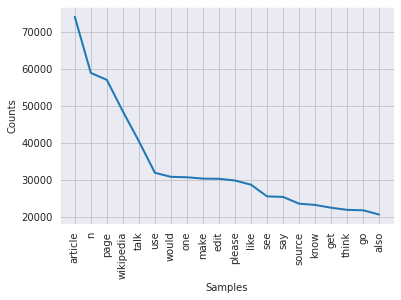

In [22]:
# строим график частотности
fdist.plot(20,cumulative=False)
plt.show()

In [20]:
!pip install Pillow==9.5.0.

     |████████████████████████████████| 3.4 MB 1.1 MB/s eta 0:00:01
  Attempting uninstall: Pillow
    Found existing installation: pillow 11.1.0
    Uninstalling pillow-11.1.0:
      Successfully uninstalled pillow-11.1.0


In [21]:
# визуализируем облако слов
text_raw = " ".join(clear_data)
wordcloud = WordCloud().generate(text_raw)
plt.figure(figsize=(10,10))
plt.imshow(wordcloud)
plt.show()

AttributeError: 'ImageDraw' object has no attribute 'textsize'

In [24]:
target = data['toxic']
features = data.drop(['toxic'], axis=1)

#features_train, features_test, target_train, target_test = train_test_split(features,target,test_size=0.4,random_state=142)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=TEST_SIZE, random_state=RANDOM_STATE,
                                                    stratify=data['toxic']) 
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((119469, 1), (39823, 1), (119469,), (39823,))

In [26]:
train_sample=X_train.shape[0]/features.shape[0]
test_sample=X_test.shape[0]/features.shape[0]

print('Размер тренировочной выборки- {:.0%}'.format(train_sample))
print('Размер тестовой выборки - {:.0%}'.format(test_sample))

Размер тренировочной выборки- 75%
Размер тестовой выборки - 25%


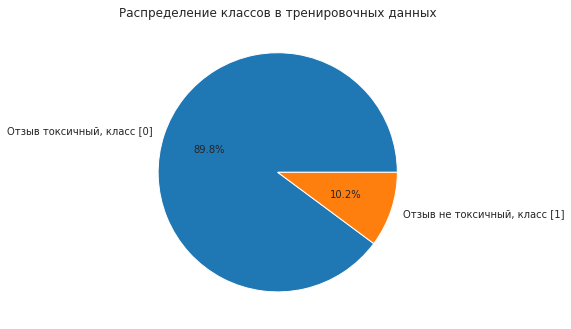

In [27]:
sns.set_style('darkgrid')
y_train.value_counts(normalize=True).plot(kind='pie',figsize=[5.5,5.5], legend=False, autopct='%1.1f%%',labels=['Отзыв токсичный, класс [0]','Отзыв не токсичный, класс [1]'])
plt.title('Распределение классов в тренировочных данных')
plt.ylabel('')
plt.show()

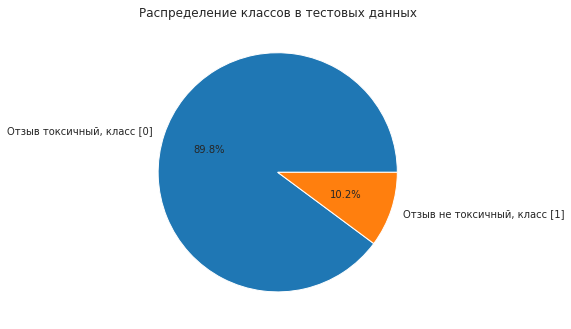

In [28]:
sns.set_style('darkgrid')
y_test.value_counts(normalize=True).plot(kind='pie',figsize=[5.5,5.5], legend=False, autopct='%1.1f%%',labels=['Отзыв токсичный, класс [0]','Отзыв не токсичный, класс [1]'])
plt.title('Распределение классов в тестовых данных')
plt.ylabel('')
plt.show()

Иммеем дисбаланс классов, проведем сэмплирование

In [29]:
def down_up_sample(features, target, fraction, repeat):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]

    features_down_up = pd.concat([features_zeros.sample(frac=fraction, random_state=12345)] + [features_ones]*repeat)
    target_down_up = pd.concat([target_zeros.sample(frac=fraction, random_state=12345)] + [target_ones]*repeat)
    
    features_down_up_sampled, target_down_up_sampled = shuffle(
        features_down_up, target_down_up, random_state=12345)
    
    return features_down_up_sampled, target_down_up_sampled

X_train, y_train  = down_up_sample(X_train, y_train, 0.8, 7)

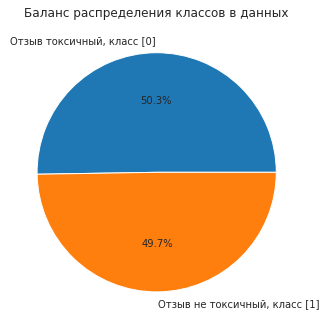

In [31]:
y_train.value_counts(normalize=True).plot(kind='pie',figsize=[5.5,5.5], legend=False, autopct='%1.1f%%',labels=['Отзыв токсичный, класс [0]','Отзыв не токсичный, класс [1]'])
plt.title('Баланс распределения классов в данных')
plt.ylabel('')
plt.show()

Данные были сильно разбалансированы в сторону негативного класса. Для подготовке данных к обучению мы применили сэмплирование, т.к. при обучении модель может принять за константное предсказание отрицательный класс и очень плохо предсказывать положительный, при этом качество метрики будет высоким, т.к. в тестовых данных так же присутствует сильный дисбаланс.

In [32]:

#stopwords = set(nltk_stopwords.words('english'))
#потребовался импорт spacy.lang.de.stop_words
#from spacy.lang.de.stop_words import STOP_WORDS

#count_tf_idf = TfidfVectorizer(stop_words=stopwords) 
count_tf_idf = TfidfVectorizer(stop_words=list(STOP_WORDS))

X_train = count_tf_idf.fit_transform(X_train['text'].values)
X_test = count_tf_idf.transform(X_test['text'].values)

In [33]:
def graph_analis(true, predict):
    f1 = f1_score(true, predict)
    plt.figure(figsize=(10,6))
    true.plot(kind='kde', linewidth=2)
    pd.Series(predict).plot(kind='kde',linewidth=2)
    plt.title('График распределения плотности предсказанных и истинных значений', y=1.01)
    plt.legend(['Истинные значения','Предсказанные значения'])
    plt.text(0.75,6,'F1= {:.2f}'.format(f1))
    plt.xlabel('')
    plt.ylabel('Плотность')
    plt.show()

In [34]:
'''
# Функция для расчета основных метрик
def metrics(model, data_X_train, data_y_train, data_X_test, data_y_test, prob=True):
    # Расчитаем основную метрику для кросс-валидации
    roc_auc_train = cross_val_score(model, data_X_train, data_y_train, scoring='roc_auc', cv=3).mean()
    
    # Сделаем предсказание
    y_pred = model.predict(data_X_test)
    
    if prob:
        probs = model.predict_proba(data_X_test)[:, 1]
    
    # Расчитаем другие метрики на тесте
    roc_auc_test = roc_auc_score(data_y_test, probs)
    accuracy = accuracy_score(y_pred, data_y_test)
    f1 = f1_score(y_pred, data_y_test)
    precision = precision_score(y_pred, data_y_test)
    recall = recall_score(y_pred, data_y_test)
#    Fbeta = fbeta_score(y_pred, data_y_test, average='macro', beta=2)
    
    return pd.DataFrame([roc_auc_train, roc_auc_test, accuracy, f1, precision, recall],# Fbeta],
                 index=['roc_auc_train', 'roc_auc_test', 'accuracy', 'f1', 'precision', 'recall'],# 'f_beta_score'],
                 columns=['metrics']).round(2)
                 '''

"\n# Функция для расчета основных метрик\ndef metrics(model, data_X_train, data_y_train, data_X_test, data_y_test, prob=True):\n    # Расчитаем основную метрику для кросс-валидации\n    roc_auc_train = cross_val_score(model, data_X_train, data_y_train, scoring='roc_auc', cv=3).mean()\n    \n    # Сделаем предсказание\n    y_pred = model.predict(data_X_test)\n    \n    if prob:\n        probs = model.predict_proba(data_X_test)[:, 1]\n    \n    # Расчитаем другие метрики на тесте\n    roc_auc_test = roc_auc_score(data_y_test, probs)\n    accuracy = accuracy_score(y_pred, data_y_test)\n    f1 = f1_score(y_pred, data_y_test)\n    precision = precision_score(y_pred, data_y_test)\n    recall = recall_score(y_pred, data_y_test)\n#    Fbeta = fbeta_score(y_pred, data_y_test, average='macro', beta=2)\n    \n    return pd.DataFrame([roc_auc_train, roc_auc_test, accuracy, f1, precision, recall],# Fbeta],\n                 index=['roc_auc_train', 'roc_auc_test', 'accuracy', 'f1', 'precision', 'rec

## Обучение

DecisionTreeClassifier

In [35]:
tree = DecisionTreeClassifier(random_state = RANDOM_STATE)

grid_params = {
    'max_depth':list(range(15,16))
}

tree_gs = GridSearchCV(tree,param_grid=grid_params, cv=3, scoring='f1', verbose=True).fit(X_train, y_train)


print(f' Лучшая метрика F1 = {tree_gs.best_score_}  при параметрах {tree_gs.best_params_}')

Fitting 3 folds for each of 1 candidates, totalling 3 fits
 Лучшая метрика F1 = 0.8013587504799125  при параметрах {'max_depth': 15}


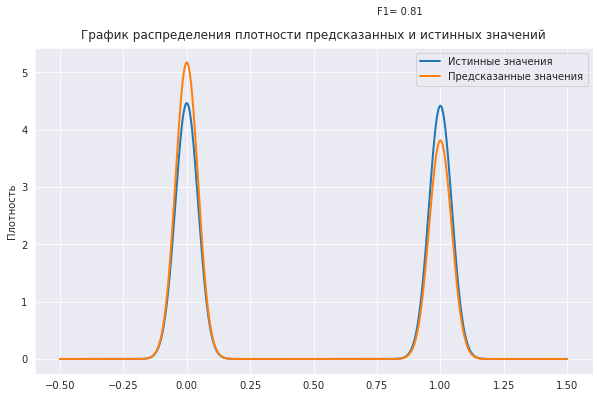

In [37]:
predicted=tree_gs.predict(X_train)
graph_analis(y_train,predicted)

RandomForestClassifier

In [ ]:
forest = RandomForestClassifier(random_state = RANDOM_STATE)

params = {
   'n_estimators':range(10,11),        
   'max_depth':list(range(15,16)) 
}

#pip_gs = make_pipeline(StandardScaler(), forest)
forest_gs = GridSearchCV(forest, param_grid=params, cv=3, scoring='f1', verbose=True).fit(X_train, y_train)

print(f' Лучшая метрика F1 = {forest_gs.best_score_}  при параметрах {forest_gs.best_params_}')

In [ ]:
predicted=forest_gs.predict(X_train)
graph_analis(y_train,predicted)

LogisticRegression

In [ ]:
lr = LogisticRegression(random_state = RANDOM_STATE, class_weight='balanced')

params = {
   #'penalty':['l1','l2'],        
   'C':[15.0],
    'intercept_scaling' : range(15,16),
    'solver' : ['liblinear']
}

#pip_gs = make_pipeline(StandardScaler(), lr)
lr_gs = GridSearchCV(lr,param_grid=params, cv=3, scoring='f1', verbose=True).fit(X_train, y_train)

print(f' Лучшая метрика F1 = {lr_gs.best_score_}  при параметрах {lr_gs.best_params_}')

In [ ]:
predicted=lr_gs.predict(X_train)
graph_analis(y_train,predicted_dt)

LightGBM:

In [57]:
model_lgbm= LGBMClassifier(random_state=RANDOM_STATE, n_jobs=2)

param_grid = {
    "max_depth" : range(1,5),
    "n_estimators" : range(56,57)
}

lgbm_model = GridSearchCV(model_lgbm, param_grid = param_grid, scoring='f1', cv=3).fit(X_train,y_train)
print(f'Лучшая f1: {lgbm_model.best_score_} при параметрах ,{lgbm_model.best_params_}')

Лучшая f1: 0.8168944634216045 при параметрах ,{'max_depth': 4, 'n_estimators': 56}


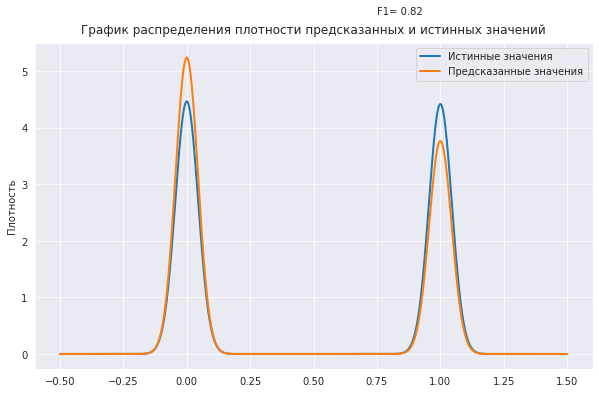

In [66]:
predicted=lgbm_model.predict(X_train)
graph_analis(y_train,predicted)

Метрики F1:

- RandomForestClassifier:Лучшая метрика F1 = 0.7653953410563202  при параметрах {'max_depth': 15, 'n_estimators': 10}
- model_lgbm: Лучшая f1: 0.8168944634216045 при параметрах ,{'max_depth': 4, 'n_estimators': 56}
- DecisionTreeClassifier: Лучшая метрика F1 = 0.8013587504799125  при параметрах {'max_depth': 15}
- LogisticRegression: Лучшая метрика F1 = 0.9774774638985232  при параметрах {'C': 15.0, 'intercept_scaling': 15, 'solver': 'liblinear'}

По метрике F1 победила LogisticRegression
Посмотрим что на  тестовых даных.

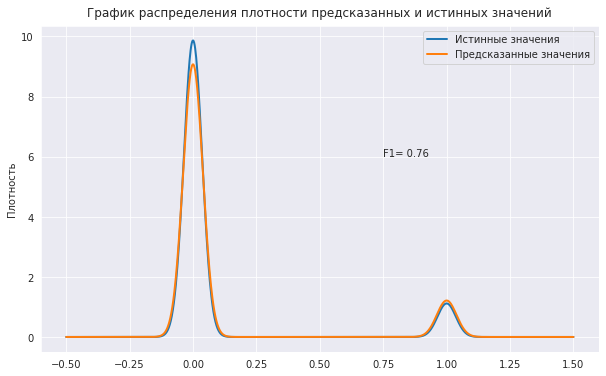

In [65]:
predicted=lr_gs.predict(X_test)
graph_analis(y_test,predicted)

## Выводы

В ходе проекта были обработаны данные для интернет-магазина ВИКИ-ШОП. В рамках запуска нового сервиса с возможностью оставлять комментарии пользователями необходимо производить поиск токсичных комментариев.

Для определения наилучшей модели выбраны следующие модели:
- RandomForestClassifier:Лучшая метрика F1 = 0.7653953410563202  при параметрах {'max_depth': 15, 'n_estimators': 10}
- model_lgbm: Лучшая f1: 0.8168944634216045 при параметрах ,{'max_depth': 4, 'n_estimators': 56}
- DecisionTreeClassifier: Лучшая метрика F1 = 0.8013587504799125  при параметрах {'max_depth': 15}
- LogisticRegression: Лучшая метрика F1 = 0.9774774638985232  при параметрах {'C': 15.0, 'intercept_scaling': 15, 'solver': 'liblinear'}

Самой эффективной моделью, которая показала максимальную метрику F1(0.76) на тестовых даных, является модель Логистической регресии. 
Требование о значении метрики F1 (не менее 0,75) выполнено.
